# Team 14 Trilemma Foundation Executive EDA

In [1]:
### === IMPORTS === ###
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import polars as pl
import math
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer
pl.Config.set_tbl_rows(2000) # ensure table displays do not truncate when there's a large number of rows

polars.config.Config

# 1. Executive Summary (Placeholder - NEEDS UPDATE/ENHANCEMENT)

The EDA in this notebook follows the expected scope of Track 1, which covers soccer analytics and prediction markets. Key findings include:
1. **Expected Goal (xG) Difference, Shots on Target (SOT) Difference, and Total Shot Difference are the strongest signals in predicting binary game outcome (Win/Loss)** amongst the events data attributes.
> *Note: `xG_diff` = (total `shot_statsbomb_xg` team A) - (total `shot_statsbomb_xg` team B)*

2. Across varying time intervals (e.g., analyzing only first half event data), *xG difference* remains the cleanest and most consistent strength proxy. With *SOT difference* surprisingly close behind. *Territory* is an early predictor but fades late. Pressure is not a key signal, as it is reactive rather than predictive. Event data occuring in overtime is substantially more noisy and structurally different than events in regulation time. 


# 2. Data Retrieval `Statsbomb Events Dataset`

In [2]:
### === DATA LODA === ###
# ----------------------------------
# Statsbomb Event Data Retrieval
# ----------------------------------
EDA_DIR = Path.cwd()  # should be .../<parent folder name>/eda
PROJECT_ROOT = EDA_DIR.parent # .../<parent folder name>

STATSBOMB_DIR = PROJECT_ROOT / "data" / "Statsbomb" # .../<parent folder name>/data/Statsbomb
EVENTS_PATH = STATSBOMB_DIR / "events.parquet" # .../<parent folder name>/data/Statsbomb/events.parquet

events_scan = pl.scan_parquet(EVENTS_PATH)
events_df = pl.read_parquet(EVENTS_PATH)

## 2.1. Preprocessing: Create Match Results Table

In [3]:
### === CREATE MATCH RESULTS TABLE === ###
# ----------------------------------
# Initiate match results table 
# ----------------------------------
match_results = (events_df.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome") == "Goal"))
    .group_by(["match_id", "team"]).agg(pl.len().alias("goals_scored")))
print("MATCH RESULTS shape | rows = (# games)x(# teams):", match_results.shape)

# left join with unique match/team combo to add teams that did not score any goals
all_team_matches = (events_df.select(["match_id", "team"]).unique()) # All team–match combinations observed in events
match_results = (all_team_matches.join(match_results, on=["match_id", "team"], how="left").with_columns(pl.col("goals_scored").fill_null(0)))
print("MATCH RESULTS Shape | rows = (# games)x(2 teams):", match_results.shape)

# ----------------------------------------
# === add match result column ===
# ----------------------------------------
print("\n\n===== MATCH RESULT Counts =====")
match_results = (match_results.with_columns([pl.col("goals_scored").max().over("match_id").alias("goals_max"),pl.col("goals_scored").min().over("match_id").alias("goals_min"),])
    .with_columns(pl.when(pl.col("goals_max") == pl.col("goals_min")).then(pl.lit("Draw"))
        .when(pl.col("goals_scored") == pl.col("goals_max")).then(pl.lit("Win")).otherwise(pl.lit("Loss")).alias("result"))
    .drop(["goals_max", "goals_min"]).sort("match_id"))
display(match_results.head(5))

MATCH RESULTS shape | rows = (# games)x(# teams): (4909, 3)
MATCH RESULTS Shape | rows = (# games)x(2 teams): (6928, 3)


===== MATCH RESULT Counts =====


match_id,team,goals_scored,result
i32,str,u64,str
7298,"""Manchester City WFC""",2,"""Draw"""
7298,"""Chelsea FCW""",2,"""Draw"""
7430,"""North Carolina Courage""",4,"""Win"""
7430,"""Washington Spirit""",2,"""Loss"""
7443,"""Portland Thorns""",2,"""Loss"""


#### Shot Outcome Types
| On Target Shot Outcome Types | Description |  \| | Off Target Shot Outcome Types | Description  |  
| :-------- | :----------------------------|  :-- | :-------- | :----------------------------| 
| `Goal` | A shot that was deemed to cross the goal-line by officials | \| | `Blocked` |  A shot that was stopped from continuing by a defender  |
| `Off T` | A shot that’s initial trajectory ended outside the posts  | \| | `Post` | A shot that hit one of the three posts  |
| `Saved` | A shot that was saved by the opposing team’s keeper  | \| | `Wayward` | An unthreatening shot that was way off target or did not have enough power to reach the goal line (or a miskick where the player didn’t make contact with the ball) |
| `Saved to Post` | If the keeper saves the shot and it bounces off the goal frame | \| | `Saved Off Target` | A shot that was saved by the goalkeeper but was not on target. |






## 2.2. Match df creation function `create_match_results_matrix(e, ot=False)`
- Note: columns goals_scored, result, goals_conceded, and goal_diff are based on the full game result (comes from the match_results dataframe). All other columns are based on the data inside of the specified time window (e.g., first half, overtime, regulation, etc.).

In [4]:
### === Build create_match_results_matrix(e, m, ot=False) function === ###
# ------------------------------------------------------------
# Build feature df in time window(s) (same columns as full-game df)
# ------------------------------------------------------------
def create_match_results_matrix(e, m, ot=False):      
    
    # carry / dribble / pass volume
    team_vol = (
        e.group_by(["match_id","team"])
         .agg([
             (pl.col("type") == "Carry").sum().alias("n_carries"),
             (pl.col("type") == "Dribble").sum().alias("n_dribbles"),
             (pl.col("type") == "Pass").sum().alias("n_passes"),
             ((pl.col("type") == "Pass") & (pl.col("pass_outcome").is_null()))
                 .sum().alias("n_passes_complete"),
         ])
    )
    
    # shots + xg
    team_shots = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.len().alias("shots"))
    team_xg = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.col("shot_statsbomb_xg").sum().alias("xg_for"))
    
    # shots on target
    sot_outcomes = ["Goal", "Saved", "Saved to Post", "Saved Off Target"]
    team_sot = (
        e.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome").is_in(sot_outcomes)))
         .group_by(["match_id","team"])
         .agg(pl.len().alias("shots_on_target"))
    )
    
    # pressures
    team_press = e.filter(pl.col("type") == "Pressure").group_by(["match_id","team"]).agg(pl.len().alias("pressures"))
    
    # final third entries (pass/carry end x > 80)
    team_ft_pass = e.filter((pl.col("type")=="Pass") & (pl.col("pass_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_passes"))
    team_ft_carry = e.filter((pl.col("type")=="Carry") & (pl.col("carry_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_carries"))

    if ot:
        # ------------------------------------------------------------
        # Build spine from provided event window (e)
        # ------------------------------------------------------------
        spine = (
            e.select(["match_id","team"])
             .unique()
        )
        
        # ------------------------------------------------------------
        # Start from event-based spine instead of m
        # ------------------------------------------------------------
        df_h1 = (
            spine
            .join(m, on=["match_id","team"], how="left")
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    else:
        # start from m spine and join features
        df_h1 = (
            m
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    
    # add opponent ("against") + diffs (cast to signed first to avoid u64 underflow)
    df_h1 = df_h1.with_columns([
        pl.col("goals_scored").cast(pl.Int64),
        pl.col("shots").cast(pl.Int64),
        pl.col("shots_on_target").cast(pl.Int64),
        pl.col("final_third_entries").cast(pl.Int64),
        pl.col("pressures").cast(pl.Int64),
    ])
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("goals_scored").sum().over("match_id").alias("match_goals_total"),
            pl.col("shots").sum().over("match_id").alias("match_shots_total"),
            pl.col("shots_on_target").sum().over("match_id").alias("match_sot_total"),
            pl.col("xg_for").sum().over("match_id").alias("match_xg_total"),
            pl.col("final_third_entries").sum().over("match_id").alias("match_ft_total"),
            pl.col("pressures").sum().over("match_id").alias("match_press_total"),
        ])
        .with_columns([
            (pl.col("match_goals_total") - pl.col("goals_scored")).alias("goals_conceded"),
            (pl.col("match_shots_total") - pl.col("shots")).alias("shots_against"),
            (pl.col("match_sot_total") - pl.col("shots_on_target")).alias("sot_against"),
            (pl.col("match_xg_total") - pl.col("xg_for")).alias("xg_against"),
            (pl.col("match_ft_total") - pl.col("final_third_entries")).alias("final_third_against"),
            (pl.col("match_press_total") - pl.col("pressures")).alias("pressure_against"),
        ])
        .with_columns([
            (pl.col("goals_scored") - pl.col("goals_conceded")).alias("goal_diff"),
            (pl.col("shots") - pl.col("shots_against")).alias("shot_diff"),
            (pl.col("shots_on_target") - pl.col("sot_against")).alias("sot_diff"),
            (pl.col("xg_for") - pl.col("xg_against")).alias("xg_diff"),
            (pl.col("final_third_entries") - pl.col("final_third_against")).alias("final_third_diff"),
            (pl.col("pressures") - pl.col("pressure_against")).alias("pressure_diff"),
        ])
        .with_columns([
            pl.col("n_carries").fill_null(0).cast(pl.Int64),
            pl.col("n_dribbles").fill_null(0).cast(pl.Int64),
            pl.col("n_passes").fill_null(0).cast(pl.Int64),
            pl.col("n_passes_complete").fill_null(0).cast(pl.Int64),
            (pl.col("n_passes_complete") / pl.when(pl.col("n_passes") > 0)
                 .then(pl.col("n_passes"))
                 .otherwise(None)).alias("pass_completion_rate")
        ])
        .drop([
            "match_goals_total","match_shots_total","match_sot_total",
            "match_xg_total","match_ft_total","match_press_total"
        ])
    )
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("n_carries").cast(pl.Int64).alias("n_carries_i"),
            pl.col("n_dribbles").cast(pl.Int64).alias("n_dribbles_i"),
            pl.col("n_passes").cast(pl.Int64).alias("n_passes_i"),
            pl.col("n_passes_complete").cast(pl.Int64).alias("n_passes_complete_i"),
        ])
        .with_columns([
            pl.col("n_carries_i").sum().over("match_id").alias("match_total_carries"),
            pl.col("n_dribbles_i").sum().over("match_id").alias("match_total_dribbles"),
            pl.col("n_passes_i").sum().over("match_id").alias("match_total_passes"),
            pl.col("n_passes_complete_i").sum().over("match_id").alias("match_total_passes_complete"),
        ])
        .with_columns([
            (pl.col("match_total_carries") - pl.col("n_carries_i")).alias("carries_against"),
            (pl.col("match_total_dribbles") - pl.col("n_dribbles_i")).alias("dribbles_against"),
            (pl.col("match_total_passes") - pl.col("n_passes_i")).alias("passes_against"),
            (pl.col("match_total_passes_complete") - pl.col("n_passes_complete_i")).alias("passes_complete_against"),
        ])
        .with_columns([
            (pl.col("n_carries_i") - pl.col("carries_against")).alias("carry_diff"),
            (pl.col("n_dribbles_i") - pl.col("dribbles_against")).alias("dribble_diff"),
            (pl.col("n_passes_i") - pl.col("passes_against")).alias("pass_diff"),
            (pl.col("n_passes_complete_i") - pl.col("passes_complete_against")).alias("pass_complete_diff"),
        ])
        .drop([
            "n_carries_i","n_dribbles_i","n_passes_i","n_passes_complete_i",
            "match_total_carries","match_total_dribbles","match_total_passes","match_total_passes_complete",
        ])
    )

    # add binary win loss column. Ties are populated with 'None' for later filtering
    df_h1 = df_h1.with_columns(
        pl.when(pl.col("result") == "Win").then(pl.lit(1))
          .when(pl.col("result") == "Loss").then(pl.lit(0))
          .otherwise(None)
          .cast(pl.Int8)
          .alias("win")
    )
    
    return df_h1

In [20]:
# create match results function 
df = create_match_results_matrix(events_df, match_results) 
# inspect 
print("Agggregate Match Results df for One Game")
display(df.head(2))

Agggregate Match Results df for One Game


match_id,team,goals_scored,result,shots,xg_for,shots_on_target,pressures,final_third_passes,final_third_carries,n_carries,n_dribbles,n_passes,n_passes_complete,final_third_entries,goals_conceded,shots_against,sot_against,xg_against,final_third_against,pressure_against,goal_diff,shot_diff,sot_diff,xg_diff,final_third_diff,pressure_diff,pass_completion_rate,carries_against,dribbles_against,passes_against,passes_complete_against,carry_diff,dribble_diff,pass_diff,pass_complete_diff,win
i32,str,i64,str,i64,f32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f32,i64,i64,i64,i64,i64,f32,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i8
7298,"""Manchester City WFC""",2,"""Draw""",9,1.107514,5,221,128,97,407,17,479,360,225,2,25,7,2.972968,386,249,0,-16,-2,-1.865454,-161,-28,0.751566,426,41,521,394,-19,-24,-42,-34,null
7298,"""Chelsea FCW""",2,"""Draw""",25,2.972968,7,249,217,169,426,41,521,394,386,2,9,5,1.107514,225,221,0,16,2,1.865454,161,28,0.756238,407,17,479,360,19,24,42,34,null


-------------

---
# 3. General Dataset Overview `Statsbomb Events Dataset`

## 3.1. Correlations

In [6]:
### === INITIAL CORRELATIONS TABLE === ###
features = ["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"]
corr_df = df.select(features).corr()
display(corr_df)

goal_diff,xg_diff,shot_diff,sot_diff,final_third_diff,pressure_diff
f64,f64,f64,f64,f64,f64
1.0,0.700917,0.468522,0.690645,0.368872,-0.275542
0.700917,1.0,0.784411,0.782583,0.596926,-0.371815
0.468522,0.784411,1.0,0.773413,0.768606,-0.439108
0.690645,0.782583,0.773413,1.0,0.604485,-0.386824
0.368872,0.596926,0.768606,0.604485,1.0,-0.580437
-0.275542,-0.371815,-0.439108,-0.386824,-0.580437,1.0


### Interpretation
#### Goal Differential Correlations
- Based on correlation magnitudes with goal differential alone, xG difference (`xg_diff`) is the strongest signal across all events data attributes. Shots on target difference (`sot_diff`) is almost as strong, followed by raw shot volume (`shot_diff`).
- We see that territory adds a good secondary signal with `final_third_diff` ${\rho}=0.37$, but less than shot quality.
- Pressures is the only feature to have a negative relationship. This may indicate teams that are being outplayed tend to apply more pressure, as `pressure_diff` is also negatively correlated with other features such as `goal_diff`, `final_third_diff`, and `shot_diff`. It may be a reactive feature. Even if so, it could still be useful for early game modeling when paired with other game stats, but noisy full-game. 
#### Multicolinearity (Predictor Variable Intra-Correlations)
- Multicolinearity amongst these top 3 predictors is present. While not formally an issue, it must be kept in mind when determining optimal modeling strategies and parameter tuning. 
> xg_diff ↔ sot_diff = 0.78, $\qquad$ xg_diff ↔ shot_diff = 0.78, $\qquad$ shot_diff ↔ final_third_diff = 0.77

## 3.2. Correlations at Varying Time Windows

In [7]:
# === APPLY create_match_results_matrix() TO FILTERED DFS ===
# -------------------------------------------------------------------
# new filtered events dfs to inspect early game / early half trends
# -------------------------------------------------------------------
print("FILTERING EVENTS DATAFRAMES...\n")
# NOTE: this is just the starting events_df object                                       # 0) All events data
events_reg = events_df.filter(((pl.col("period") <= 2)))                                 # 0) Regulation:
events_first_half = events_reg.filter(pl.col("period") == 1)                             # 1) First half only
events_q1_q3 = events_reg.filter(((pl.col("period") == 1) & (pl.col("minute") <= 22)) |
                                 ((pl.col("period") == 2) & (pl.col("minute") <= 67)))   # 2) Q1 + Q3:
events_q4 = events_reg.filter(((pl.col("period") == 2) & (pl.col("minute") > 22)))       # 3) Q4:
events_ot = events_df.filter(((pl.col("period") > 2)))                                   # 4) Overtime:

# quick sanity prints
print("=== TIMEFRAME EVENTS DFs SHAPES ===")
print("       All Events:", events_df.shape)
print("First Half Events:", events_first_half.shape)
print("     Q1+Q3 Events:", events_q1_q3.shape)
print("        Q4 Events:", events_q4.shape)
print("  Overtime Events:", events_ot.shape)
print("  Regulation Time:", events_reg.shape)

# -------------------------------------------------------------------
# convert to match results dataframe structure using custom function
# -------------------------------------------------------------------
print("\n\nSTARTING create_match_results_matrix CALLS...\n")
# df = create_match_results_matrix(events_df, match_results)                 # NOTE: already created/called in previous cell
df_h1 = create_match_results_matrix(events_first_half, match_results) 
df_q1_q3 = create_match_results_matrix(events_q1_q3, match_results) 
df_q4 = create_match_results_matrix(events_q4, match_results) 
df_ot = create_match_results_matrix(events_ot, match_results, ot=True) 
df_reg = create_match_results_matrix(events_reg, match_results) 

# quick sanity prints
print("=== TIMEFRAME MATCH RESULTS DFs SHAPES ===")
print("       All Events:", df.shape)
print("First Half Events:", df_h1.shape)
print("     Q1+Q3 Events:", df_q1_q3.shape)
print("        Q4 Events:", df_q4.shape)
print("  Overtime Events:", df_ot.shape)
print("  Regulation Time:", df_reg.shape)

FILTERING EVENTS DATAFRAMES...
=== TIMEFRAME EVENTS DFs SHAPES ===
events_df        : (12188949, 112)
events_first_half: (6139005, 112)
events_q1_q3     : (6123353, 112)
events_q4        : (5995911, 112)
events_ot        : (54033, 112)
events_reg       : (12134916, 112)


STARTING create_match_results_matrix CALLS...
=== TIMEFRAME MATCH RESULTS DFs SHAPES ===
df      : (6928, 37)
df_h1   : (6928, 37)
df_q1_q3: (6928, 37)
df_q4   : (6928, 37)
df_ot   : (110, 37)
df_reg  : (6928, 37)


In [8]:
# ==== CALUCULATE CORRELATION MATRICES ON ALL FILTERED EVENTS DATA ===
# -------------------------------------------------------------------
# correlations of filtered match results data
# -------------------------------------------------------------------
features = ["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"]
corr_df = df.select(features).corr() # All events correlations
corr_df_h1 = df_h1.select(features).corr() # First Half events correlations
corr_df_q1_q3 = df_q1_q3.select(features).corr() # Q1 and Q3 events correlations
corr_df_q4 = df_q4.select(features).corr() # Q4 events correlations
corr_df_ot = df_ot.select(features).corr() # Overtime events correlations
corr_df_reg = df_reg.select(features).corr() # Regulation events correlations

In [9]:
# === BUILD CORRELATION COMPARISON FUNCTION ===
# -------------------------------------------------------------------
# custom function to compare correlations across multiple dfs visually
# -------------------------------------------------------------------

def corr_series(corr_df, target, features, label):
    cols = corr_df.columns
    i = cols.index(target)
    vals = corr_df.row(i)
    return pd.Series({c: float(v) for c, v in zip(cols, vals) if c in features}, name=label)

def plot_corrs(targets, corr_dfs, features=None, magnitude=False, figsize=(14, 5)):
    """
    targets: list[str]                       e.g. ["goal_diff", "xg_diff"]
    corr_dfs: dict[str, polars.DataFrame]    e.g. {"All": corr_df, "H1": corr_df_h1, "Q1+Q3": corr_df_q13, "Q4": corr_df_q4}
    features: list[str]                      x-axis features (sorted alphabetically for consistent order)
    """
    if features is None:
        features = ["goal_diff", "xg_diff", "sot_diff", "shot_diff", "final_third_diff", "pressure_diff"]
    # features = sorted(features)

    for target in targets:
        series_list = [
            corr_series(df, target, features, label)
            for label, df in corr_dfs.items()
        ]

        plot_df = pd.concat(series_list, axis=1).loc[features]
        plot_data = plot_df.abs() if magnitude else plot_df

        ax = plot_data.plot(kind="bar", figsize=figsize, width=0.8)
        if not magnitude:
            ax.axhline(0, linewidth=1)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", label_type="edge", padding=2, fontsize=7)

        ax.set_title(f"{'|corr|' if magnitude else 'corr'} with {target}")
        ax.set_ylabel(f"{'|corr|' if magnitude else 'corr'}")
        ax.set_xlabel("")
        ax.legend(title="")
        plt.xticks(rotation=0)
        plt.grid(True, which="major", axis="y", linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()

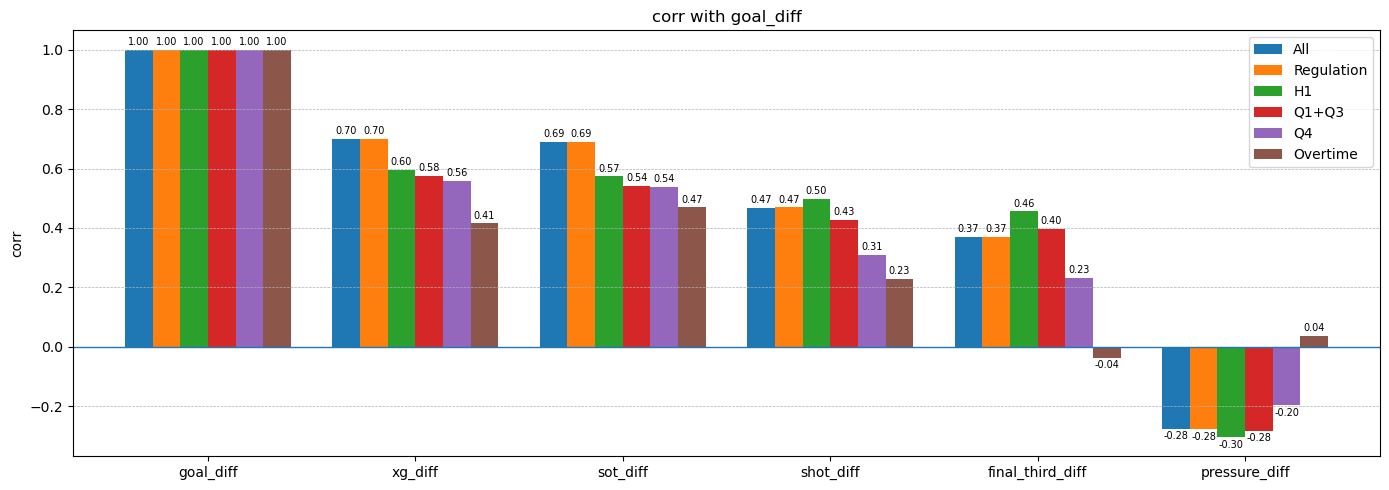

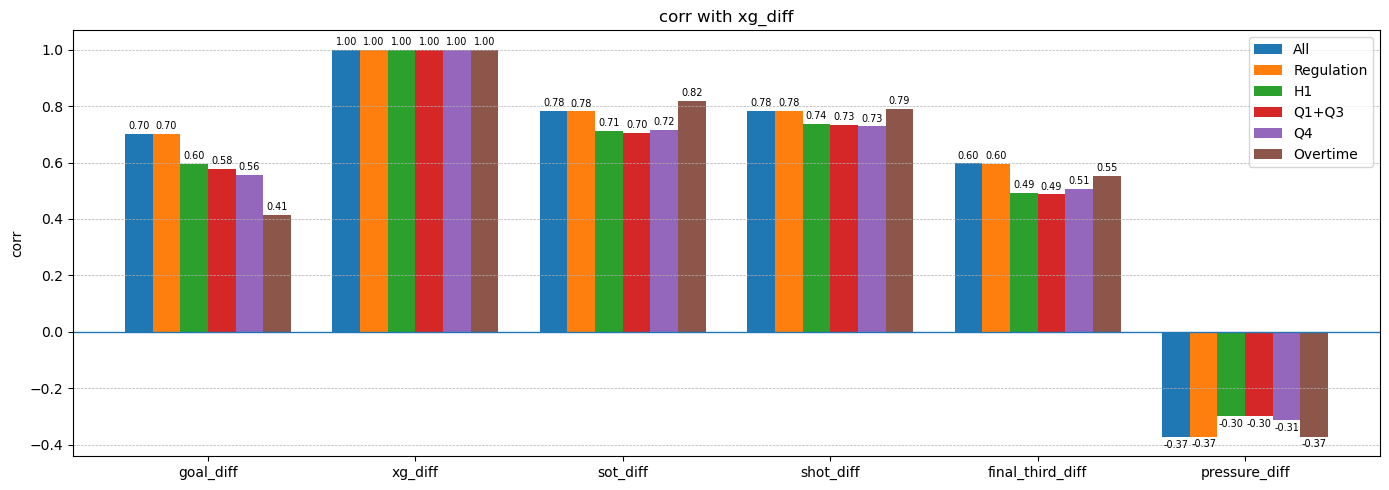

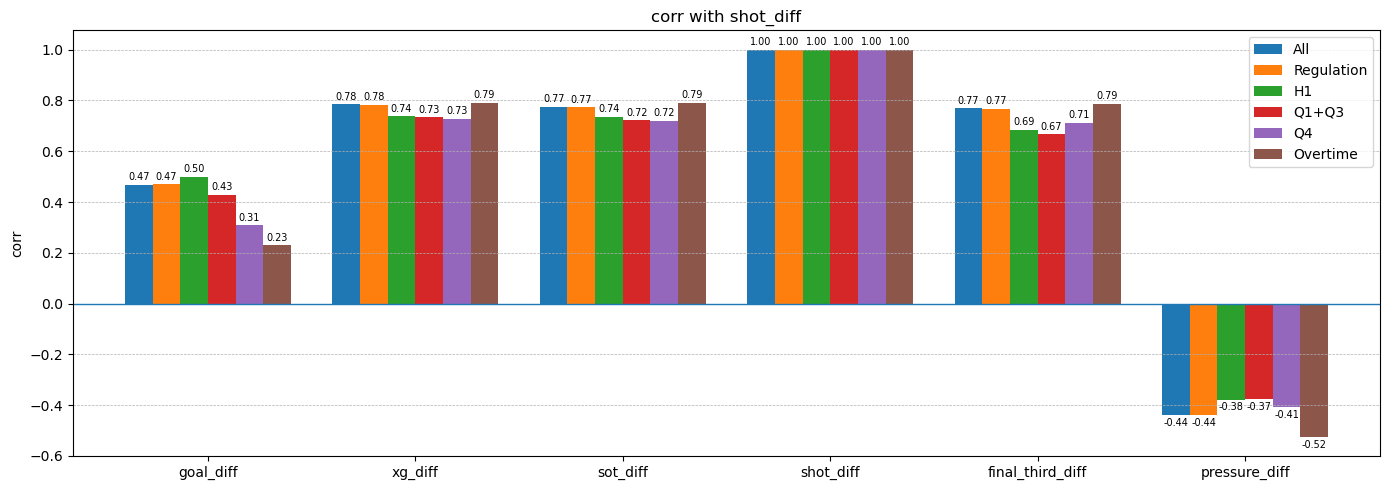

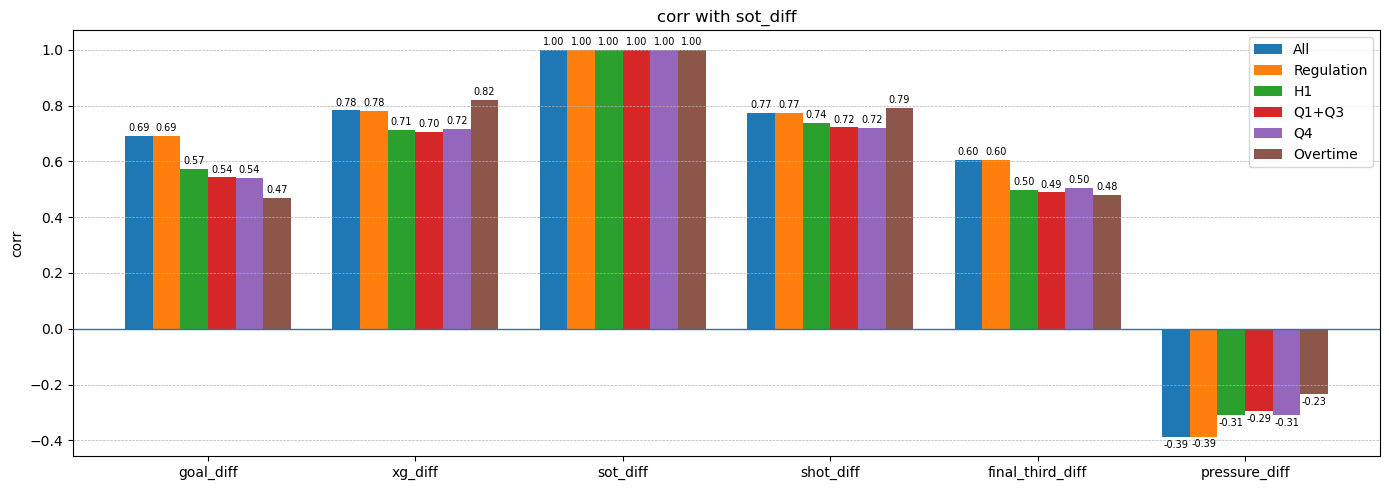

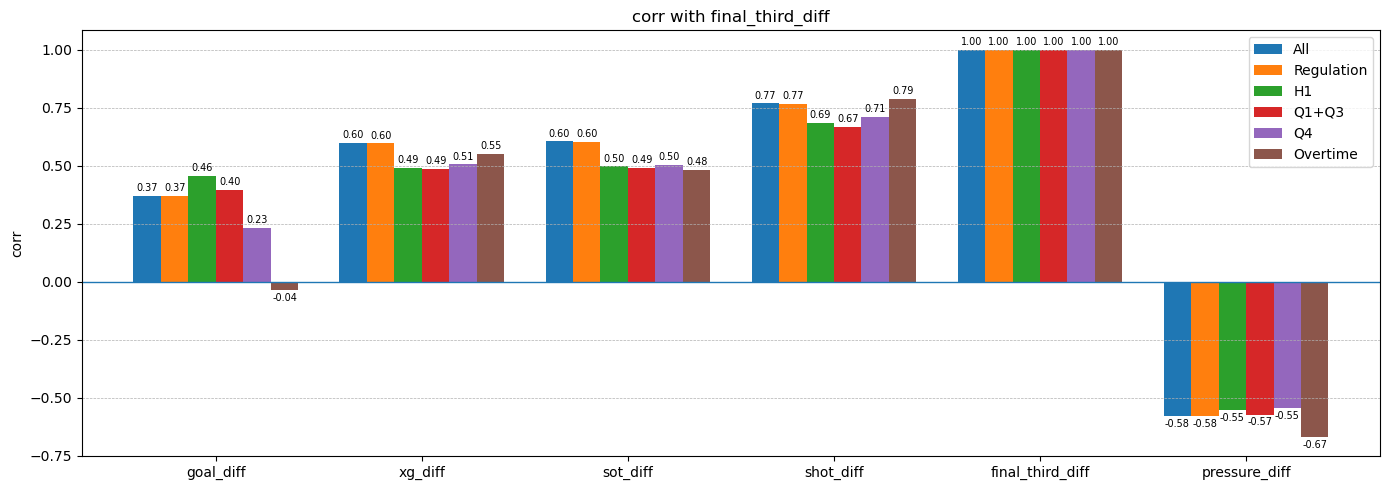

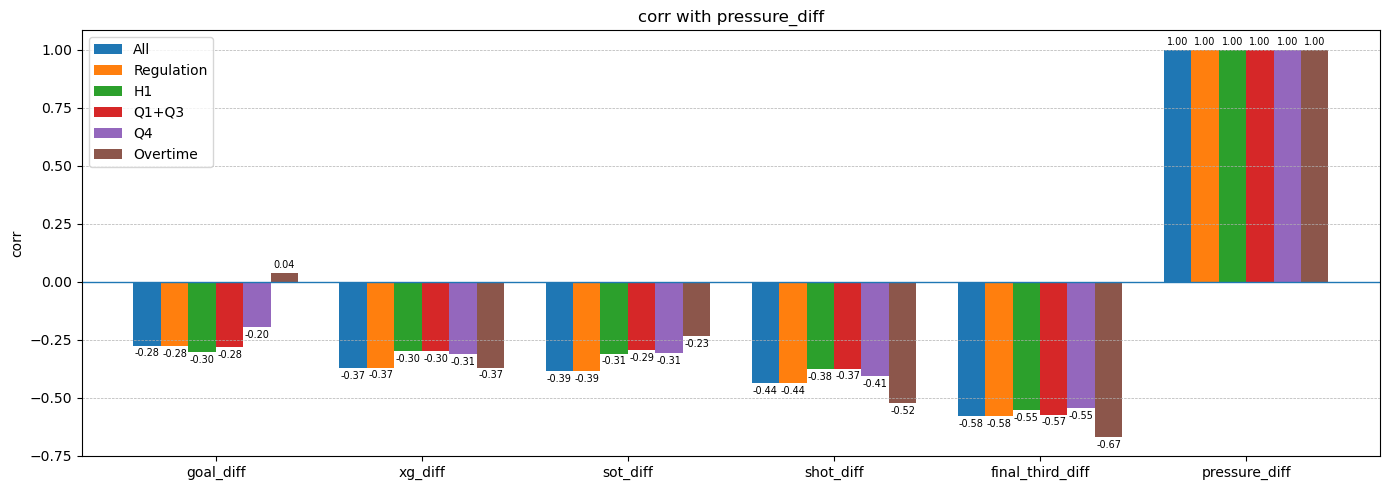

In [10]:
# === APPLY CORR COMPARISON FUNCTION corr_series() TO FILTERED DFs ===
# -------------------------------------------------------------------
# calls correlation function across filtered dfs
# -------------------------------------------------------------------
corr_dfs = {"All": corr_df,"Regulation": corr_df_reg,"H1": corr_df_h1,"Q1+Q3": corr_df_q1_q3,"Q4": corr_df_q4,"Overtime": corr_df_ot}
plot_corrs(["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"],corr_dfs,magnitude=False)

### Interpretation

#### Correlations with Goal Differential at varying time windows
- xG difference is the most stable predictor across time windows. Shots on target difference is nearly as strong. However, shot volume is weaker and decays late. We see shot diff drops sharply in Q4 and OT, implying late-game shot volume likely becomes game-state driven (losing teams shoot more)
- Final third entries remain are moderate, but are unstable across varying time windows. It is reasonabley strong early (0.46 H1), but weak or useless in late game prediction power (e.g., Q4 and OT). 
- Pressure diff is again negatively correlated and weaker. This further validates the theory that teams that are trailing often press more.
#### Time Window Signal Strength for Goal Differential Prediction
- Full match data generally has the strongest correlations magnitudes, which is expected. Fourth quarter and overtime are the least strong, indicating increased randomness and noise as the game progresses. First half data is second to full match data, suggesting it is the best candidate of the tested time windows for predictive modeling **before** the game ends. Q1+Q3 is also viable, but less so than H1. 
- In Overtime, final_third_diff and pressure_diff both are nearly 0. So in overtime, only shot quality and SOT matter. Territory and pressure completely collapse.
| H1 | Q1+Q3 | Q4 | OT |
| :--- | :--- | :--- | :--- |
| Viable | Viable | Unstable | Noisy |
#### Clear Takeaways
1. xG difference is the cleanest and most consistent strength proxy.
2. SOT difference is surprisingly strong.
3. Territory is an early predictor but fades late.
4. Pressure is reactive, not predictive.
5. Overtime is noisy and structurally different.
---

# NOTE TO SELF - CORRELATION INTERPRETATION COMMENTARY DOES NOT ACCOUNT FOR df_reg CORRELATIONS

---
## 3.2. Initial Modeling

### Setup, Simplification and Assumptions
* Logistic Regression (LR) was the main model strategy used in this report. As a result, datasets were filtered to exclude matches ending in a tie to better conform to LR's desired rbinary esponse variable structure. Furthermore, dropping draws rows results in perfect balance ($\# \text{ wins} = \# \text{ losses}$) which is ideal for logistic regression. No class imbalance exists, so no weighting is needed. The data was also filtered to only include events occurring in regulation as later periods, especially overtime, were extra noisy. 

In [11]:
# === FUNCTION TO PREPARE X AND y FOR MODELING: inputs = dataframe, feature vars (list); Returns = X (np.ndarray), y (np.ndarray) ===
def prepare_model_data(df, feature_cols):
    # print("Starting # of rows   :", df.shape[0])
    model_df = df.filter(pl.col("win").is_not_null())
    # print("Post filter # of rows:", model_df.shape[0])
    X = model_df.select(feature_cols).to_pandas()
    y = model_df.select("win").to_numpy().ravel()
    return X, y

In [12]:
# === CUSTOM FUNCTION TO SAVE MODEL PERFORMANCE METRICS FOR LATER COMPARISON ===
def cv_metrics(acc_scores, auc_scores, model_name):
    return pd.DataFrame([{
        "model (CV)": model_name,
        "acc_mean": np.mean(acc_scores),
        "acc_std":  np.std(acc_scores),
        "auc_mean": np.mean(auc_scores),
        "auc_std":  np.std(auc_scores),
    }]).round(3)

In [13]:
# === CUSTOM BIC FUNCTION FOR MODEL SELECTION / EVALUATION ===
def compute_bic(X, y):
    X_const = sm.add_constant(X)
    model = sm.Logit(y, X_const).fit(disp=False)
    return model.bic, model

---
## Model 1
---

In [14]:
# === MODEL 1 ===
# -------------------------------------------------------------------
# Filter and inspect 
# -------------------------------------------------------------------
print("=== 1. DATA INSPECTION ============")
# FILTER FOR WINS AND LOSES ONLY (REMOVE TIES)
df_reg_no_ties = (df_reg.filter(pl.col("result").is_in(["Win", "Loss"])))
# quick distribution inspection
display(df_reg_no_ties.select([pl.col("xg_diff").mean().alias("mean_xg_diff"),pl.col("xg_diff").std().alias("std_xg_diff")]))
display(df_reg_no_ties.group_by("win").agg(pl.col("xg_diff").mean().alias("mean_xg_diff")))
display(df_reg_no_ties.select(
    pl.col("xg_diff").quantile(0.25).alias("xG Diff q0.25"),
    pl.col("xg_diff").quantile(0.5).alias("xG Diff q0.50"),
    pl.col("xg_diff").quantile(0.75).alias("xG Diff q0.75")
))

# -------------------------------------------------------------------
# Simple Model 1 
# -------------------------------------------------------------------
print("\n\n=== 2. Simple MODEL 1 =============")

# === LR MODEL | ONE FEATURE, REGULATION TIME ONLY ===
# prepare data
X, y = prepare_model_data(df_reg, feature_cols=["xg_diff"])


# Fit logistic regression
model1 = LogisticRegression()
model1.fit(X, y)

# Extract coefficients
model1_beta_0 = model1.intercept_[0]
model1_beta_1 = model1.coef_[0][0]

print("  Intercept (Beta_0):", round(model1_beta_0, 2))
print("Coefficient (Beta_1):", round(model1_beta_1, 2))

# accuracy and AUC
probs1 = model1.predict_proba(X)[:,1]
preds1 = model1.predict(X)

accuracy1 = accuracy_score(y, preds1)
auc1 = roc_auc_score(y, probs1)

print("            Accuracy:", round(accuracy1, 2))
print("                 AUC:", round(auc1, 2))

# -------------------------------------------------------------------
# Cross Validation Model 1 
# -------------------------------------------------------------------
print("\n\n=== 3. Cross Validation MODEL 1 ===")

# === CROSS VALIDATION LR MODEL | ONE FEATURE, REGULATION TIME ONLY ===

model1 = LogisticRegression()
# Results: Accuracy and AUC
acc_scores1 = cross_val_score(model1, X, y, cv=10, scoring="accuracy")
auc_scores1 = cross_val_score(model1, X, y, cv=10, scoring="roc_auc")
logreg_cv_results = cv_metrics(acc_scores1, auc_scores1, "LogReg: xg_diff")
display(logreg_cv_results)

=== 1. DATA INSPECTION ============


mean_xg_diff,std_xg_diff
f32,f32
8.3279e-10,1.486408


win,mean_xg_diff
i8,f32
0,-0.916865
1,0.916865


xG Diff q0.25,xG Diff q0.50,xG Diff q0.75
f32,f32,f32
-0.952118,0.000411,0.952118




=== 2. Simple MODEL 1 =============
  Intercept (Beta_0): -0.0
Coefficient (Beta_1): 1.53
            Accuracy: 0.79
                 AUC: 0.88


=== 3. Cross Validation MODEL 1 ===


,model (CV),acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.04


## Model 1 Intepretation
Model     | Model Type/Name     | Features                       | Train Data (X)              |Data Obj Name|Test Data (X)| CV?
:-------- | :------------------ | :----------------------------- |:--------------------------- | :---------- |:----------- | :-
Model 1   | LogReg              | xg_diff                        | Regulation time events      | `df_reg`    | `df_reg`    | Yes

### 1. Data Inspection (Regulation Time events)
    When looking at differences, and means of differences, they are symmetric (i.e., average xG difference has equal magnitudes for wins and losses, and the overall mean is 0). This because for every positive expected goal different, their opponent has an equal but negative xG difference. We see that:
- Distribution is symmetric around 0.
- Interquartile range ≈ 1.90.
- The class means (±0.917) are almost exactly at the 25th and 75th percentiles.
- **Thus implying our LR cutoff value should be 0.5.**
$$
\text{xg\_diff} \ge 0 \implies P(\text{Win}) \ge 0.5
$$
$$
\text{xg\_diff} < 0 \implies P(\text{Win}) < 0.5
$$

### 2. Coefficient $(\beta)$ Inspection
- The intercept $(\beta_0 = 0)$ implies that the probability of winning given an expected goal difference of 0 is 50%.
$$
P(\text{Win} \mid \text{xg\_diff} = 0) = 0.5
$$
- The slope $ (\beta_1 = 1.53)$ implies that for every +1.0 increase in xG differential multiplies the odds of winning by about 4.6x.
$$
\text{+1 xG advantage} \implies \text{log-odds increase by } 1.53 = \exp(1.53) \approx 4.62
$$

- The average xG differential for wins is 0.9169, meaning the model predicts about an 80% chance of winning. This is extremely reasonable. 

$$
\implies \text{logit} = 1.53 \times 0.9169 = 1.40
$$

$$
\implies  P(\text{Win}) = \frac{1}{1 + e^{-1.40}} \approx 0.80
$$

### 3. Cross-Validation Results
    Standard deviations are small, meaning the model generalizes well. Performance does not swing wildly across folds. This further validates that xg_diff is a consistent predictor, not sample noise. Accuracy is approx. 78.8%. With a baseline of 50%, thats a +28.8 percentage points from using just one feature. AUC of 0.87 indicates a very strong model. 

---

---
## Model 2
### Logistic Regression with variable selection (forward search BIC)
---

In [15]:
# === MODEL 2 FORWARD SEARCH LR MODEL ===
# -------------------------------------------------------------------
# Model 2 Forward Selection Diff Vars only
# -------------------------------------------------------------------
print("\n\n=== 1. MODEL 2 FORWARD SEARCH diff features only ===")
# Candidate predictors
candidates = ["shot_diff","sot_diff","final_third_diff","pressure_diff","carry_diff","dribble_diff","pass_diff","pass_complete_diff",]
X, y = prepare_model_data(df_reg, feature_cols=candidates)
selected = []
remaining = candidates.copy()
current_bic = np.inf
print("Starting Forward Selection (BIC)\n")
while len(remaining) > 0:
    bic_with_candidates = []
    for candidate in remaining:
        X_candidate = X[selected + [candidate]]
        bic, _ = compute_bic(X_candidate, y)
        bic_with_candidates.append((bic, candidate))
    bic_with_candidates.sort()
    best_bic, best_candidate = bic_with_candidates[0]
    if best_bic < current_bic:
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_bic = best_bic
        print(f"Added: {best_candidate} | BIC: {round(best_bic, 2)}")
    else:
        break

print("\nFinal selected variables (diff features only, no xg_diff):", selected)



# -------------------------------------------------------------------
# Model 2 Forward Selection All Vars
# -------------------------------------------------------------------
print("\n\n=== 2. MODEL 2 FORWARD SEARCH All Vars ===")
# === FORWARD SEARCH LR MODEL | ALL PREDICTORS | REGULATION TIME ===

# Candidate predictors
candidates = [
    'shots', 'shots_on_target', 'pressures', 'final_third_passes', 'final_third_carries', 'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'final_third_entries', 
    'shots_against', 'sot_against', 'final_third_against', 'pressure_against', 'shot_diff', 'sot_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 
    'carries_against', 'dribbles_against', 'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff']
X, y = prepare_model_data(df_reg, feature_cols=candidates)
selected = []
remaining = candidates.copy()
current_bic = np.inf
print("Starting Forward Selection (BIC)\n")
while len(remaining) > 0:
    bic_with_candidates = []
    for candidate in remaining:
        X_candidate = X[selected + [candidate]]
        bic, _ = compute_bic(X_candidate, y)
        bic_with_candidates.append((bic, candidate))
    bic_with_candidates.sort()
    best_bic, best_candidate = bic_with_candidates[0]
    if best_bic < current_bic:
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_bic = best_bic
        print(f"Added: {best_candidate} | BIC: {round(best_bic, 2)}")
    else:
        break
print("\nFinal selected variables (all features, no xg diff, for, against, etc.):", selected)


# -------------------------------------------------------------------
# Model 2 Logistic Regression with 3 Forward Selected Variables
# -------------------------------------------------------------------
print("\n\n=== 3. MODEL 2 LogReg with 3 FORWARD SELECTED All VARS ===")
# === LR MODEL PERFORMANCE | FORWARD SEARCH PREDICTORS | REGULATION TIME ===
features_selected = ["sot_diff", "xg_diff", "shot_diff"]

X_sel, y = prepare_model_data(df_reg, feature_cols=features_selected)

model2 = LogisticRegression()

acc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="accuracy")
auc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="roc_auc")

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores2, auc_scores2, "LogReg: sot_diff + xg_diff + shot_diff")
], ignore_index=True).drop_duplicates()

logreg_cv_results



=== 1. MODEL 2 FORWARD SEARCH diff features only ===
Starting Forward Selection (BIC)

Added: sot_diff | BIC: 4684.98
Added: shot_diff | BIC: 4580.92
Added: carry_diff | BIC: 4577.77
Added: pass_diff | BIC: 4533.81
Added: pass_complete_diff | BIC: 4303.24

Final selected variables (diff features only, no xg_diff): ['sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']


=== 2. MODEL 2 FORWARD SEARCH All Vars ===
Starting Forward Selection (BIC)

Added: sot_diff | BIC: 4684.98
Added: shot_diff | BIC: 4580.92
Added: carry_diff | BIC: 4577.77
Added: pass_diff | BIC: 4533.81
Added: pass_complete_diff | BIC: 4303.24

Final selected variables (all features, no xg diff, for, against, etc.): ['sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']


=== 3. MODEL 2 LogReg with 3 FORWARD SELECTED All VARS ===


,model (CV),acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.04
1,LogReg: sot_diff + xg_diff + shot_diff,0.843,0.027,0.922,0.02


## Model 2 Interpretation
Model     | Model Type/Name     | Features                       | Train Data (X)              |Data Obj Name|Test Data (X)| CV?
:-------- | :------------------ | :----------------------------- |:--------------------------- | :---------- |:----------- | :-
Model 1   | LogReg              | xg_diff                        | Regulation time events      | `df_reg`    | `df_reg`    | TBD
Model 2   | LR w/ Forward Search| sot_diff, xg_diff, shot_diff   | Regulation time events      | `df_reg`    | `df_reg`    | TBD

$\quad$ BIC was used as the performance metrics over AIC as we are investigating model selection, rather than aiming to improve predictive accuracy. BIC also penalizes model complexity more strongly than AIC, which is favorable at this stage in the EDA.

$\quad$ Due to high multicollinearity and derived variable, two forward search LR models were created to compare which variables were selected for each. The first model only used differential features. For example, pass_diff was used, but not n_passes or passes_against. The second model used all viable predictor variables. It is also worth noting that goal_diff is not considered as a viable predictor variable, as that feature is the realized outcome of the full game time. 

$\quad$ Both forward search algorithm models choose sot_diff, xg_diff, and shot_diff. Additionally, sot_diff was chosen before xg_diff, which is interesting considering the correlation analysis predicted xg_diff to be the strongest predictor. This is likely because BIC favors simpler models, meaning sot_diff is slightly better in likelihood-to-penalty tradeoff. Also, the three features selected are all highly correlated as noted previously (>0.7 to each other). Even correlated predictors can add incremental likelihood improvements if they capture slightly different aspects. This result is promising for the possible performance of a PCA model. 
    
$\quad$ There was a substantial improvement is model performance, meaning shot volume and SOT add real incremental predictive signal, even with xg_diff alone being very strong. xG captures shot quality, but it does not capture shot frequency dominance, finishing precision (SOT), or situations where volume matters over quality. 

---


---
## Model 3: PCA -> choose top k predictors -> Logistic Regression
---

=== 1. MODEL 3 PCA Analysis ===
Top 10 Principal Components


,PC,Explained Variance Ratio,Cumulative Variance
0,1,0.581528,0.581528
1,2,0.075590,0.657118
2,3,0.070430,0.727548
3,4,0.050556,0.778105
4,5,0.045190,0.823294
5,6,0.040407,0.863701
6,7,0.034932,0.898633
7,8,0.028528,0.927160
8,9,0.026005,0.953165
9,10,0.017691,0.970856




=== 2. MODEL 3 FIT PCA LR MODEL WITH TOP K PCs ===


,n_components,acc_mean,acc_se,auc_mean,auc_se
0,1,0.666,0.039,0.725,0.042
1,2,0.724,0.023,0.800,0.024
2,3,0.723,0.022,0.800,0.023
3,4,0.744,0.018,0.818,0.021
4,5,0.745,0.019,0.819,0.021
5,6,0.743,0.020,0.822,0.021
6,7,0.762,0.018,0.844,0.017
7,8,0.761,0.018,0.844,0.017
8,9,0.767,0.019,0.854,0.017
9,10,0.804,0.014,0.882,0.014


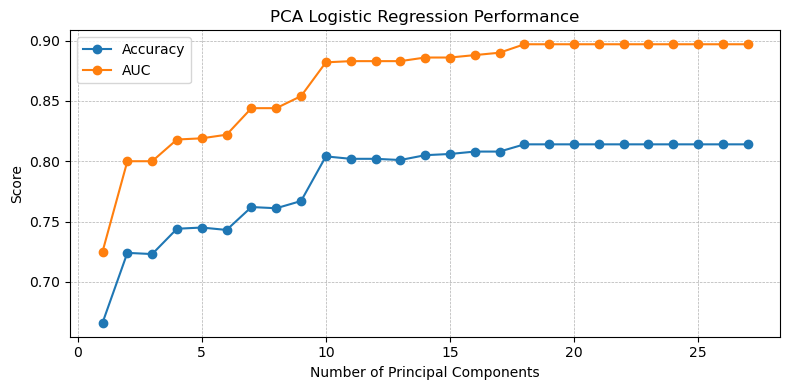



=== 3. PCA MODEL WITH BEST K ===
Best k = 10


,model (CV),acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.040
1,LogReg: sot_diff + xg_diff + shot_diff,0.843,0.027,0.922,0.020
2,PCA LogReg (k=10),0.804,0.028,0.882,0.027


In [16]:
# === PCA LR MODEL | ALL PREDICTORS | REGULATION TIME ===

# -------------------------------------------------
# 1. Run PCA Analysis
# -------------------------------------------------
print("=== 1. MODEL 3 PCA Analysis ===")
# A. Select all numeric predictors except target
feature_cols = [
    'shots', 'xg_for', 'shots_on_target', 'pressures', 'final_third_passes', 'final_third_carries', 'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'final_third_entries', 
    'shots_against', 'sot_against', 'xg_against', 'final_third_against', 'pressure_against', 'shot_diff', 'sot_diff', 'xg_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 
    'carries_against', 'dribbles_against', 'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff']
X_raw, y = prepare_model_data(df_reg, feature_cols=candidates)

# B. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# C. Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# D. Explained variance
explained_variance = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)})
print("Top 10 Principal Components")
display(explained_variance.head(10))


# -------------------------------------------------
# 2. FIT PCA LR MODEL WITH TOP K PCs
# -------------------------------------------------
print("\n\n=== 2. MODEL 3 FIT PCA LR MODEL WITH TOP K PCs ===")
results_pca = []
for k in range(1, explained_variance.shape[0] + 1):
    X_k = X_pca[:, :k]
    model = LogisticRegression()
    acc_scores = cross_val_score(model, X_k, y, cv=5, scoring="accuracy")
    auc_scores = cross_val_score(model, X_k, y, cv=5, scoring="roc_auc")
    results_pca.append({
        "n_components": k,
        "acc_mean": acc_scores.mean(),
        "acc_se": acc_scores.std(ddof=1) / np.sqrt(5),
        "auc_mean": auc_scores.mean(),
        "auc_se": auc_scores.std(ddof=1) / np.sqrt(5),
    })
pca_results_df = pd.DataFrame(results_pca).round(3)
display(pca_results_df.head(18))

# plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pca_results_df["n_components"], pca_results_df["acc_mean"], marker='o', label="Accuracy")
ax.plot(pca_results_df["n_components"], pca_results_df["auc_mean"], marker='o', label="AUC")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Score")
ax.set_title("PCA Logistic Regression Performance")
ax.legend()
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 3. SAVE RESULTS FOR PCA MODEL WITH BEST K
# -------------------------------------------------
print("\n\n=== 3. PCA MODEL WITH BEST K ===")

# choose best k by AUC elbow rule
best_k = 10
print("Best k =", best_k)

# recompute CV scores for best_k
X_best = X_pca[:, :best_k]
model = LogisticRegression()

# save results
acc_best = cross_val_score(model, X_best, y, cv=5, scoring="accuracy")
auc_best = cross_val_score(model, X_best, y, cv=5, scoring="roc_auc")
pca_best_row = cv_metrics(acc_best, auc_best, f"PCA LogReg (k={best_k})")

# append to running results df
logreg_cv_results = pd.concat([logreg_cv_results, pca_best_row], ignore_index=True).drop_duplicates()
display(logreg_cv_results)

## Model 3 Interpretation
Model     | Model Type/Name     | Features                       | Train Data (X)              |Data Obj Name|Test Data (X)| CV?
:-------- | :------------------ | :----------------------------- |:--------------------------- | :---------- |:----------- | :-
Model 1   | LogReg              | xg_diff                        | Regulation time events      | `df_reg`    | `df_reg`    | TBD
Model 2   | LR w/ Forward Search| sot_diff, xg_diff, shot_diff   | Regulation time events      | `df_reg`    | `df_reg`    | TBD
Model 3   | LR with PCA         | Top $k$ Principal Components   | Regulation time events      | `df_reg`    | `df_reg`    | TBD

$\quad$ All possible predictors were used for this model, as PCA resolves any redundancy by nature. We observe that PC1 dominates, explaining 56% of the variance, and PC2 adds about 9%. Then, we run regression on the top $k$ principal components at varying $k$'s.

$\quad$ Logistic regression with regularization (L2 penalty) is stable under multicollinearity and primarily optimized for prediction, not inference. So highly correlated features do not necessarily harm prediction. This is why we do not see the PCA model outperforming the forward search model. However, collinearity does harm coefficient interpretability, standard errors, and inference stability. PCA avoids some of these pitfats as it produces orthogonal components (PC₁ ⟂ PC₂ ⟂ PC₃ ⟂ … ), so no multicollinearity exists by construction. Instead, coefficients are stable and dimensions are independent. 

$\quad$ While the forward search and PCA models are similar in performance, the real tradeoff is interpretability. The Forward Search Model uses only 3 variables, making it highly interpretable, and achieves an AUC of 0.922. The PCA Model uses 7–10 components, making it much harder to interpret, while achieving a slightly worse AUC of 0.914

$\quad$ The main takeaway from the results of the PCA model is that multicollinearity is not hurting predictive performance (in the case of non-PCA models). However, it would matter for any future hypothesis testing and interpretion of coefficient magnitudes, but these are not analyzed in this report. This report focuses on optimizing prediction.

---

---
## Model 4: Logistic Regression on first half data only
---

In [17]:
# -------------------------------------------------
# 1. LogReg Model on first half data only (train and test)
# -------------------------------------------------
print("=== 1. MODEL 4 First Half LogReg Model ===")
features_selected = ["sot_diff", "xg_diff", "shot_diff"]
X_sel, y = prepare_model_data(df_h1, feature_cols=features_selected)

### Run and test model with the 3 predictors ###
model4 = LogisticRegression()

acc_scores4 = cross_val_score(model4, X_sel, y, cv=5, scoring="accuracy")
auc_scores4 = cross_val_score(model4, X_sel, y, cv=5, scoring="roc_auc")

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores4, auc_scores4, "LogReg H1")
], ignore_index=True).drop_duplicates()

logreg_cv_results

=== 1. MODEL 4 First Half LogReg Model ===


,model (CV),acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.040
1,LogReg: sot_diff + xg_diff + shot_diff,0.843,0.027,0.922,0.020
2,PCA LogReg (k=10),0.804,0.028,0.882,0.027
3,LogReg H1,0.766,0.029,0.841,0.038


## Model 4 Interpretation
Model     | Model Type/Name     | Features                       | Train Data (X)              |Data Obj Name|Test Data (X)| CV?
:-------- | :------------------ | :----------------------------- |:--------------------------- | :---------- |:----------- | :-
Model 1   | LogReg              | xg_diff                        | Regulation time events      | `df_reg`    | `df_reg`    | TBD
Model 2   | LR w/ Forward Search| sot_diff, xg_diff, shot_diff   | Regulation time events      | `df_reg`    | `df_reg`    | TBD
Model 3   | LR with PCA         | Top $k$ Principal Components   | Regulation time events      | `df_reg`    | `df_reg`    | TBD
Model 4   | LogReg H1           | sot_diff, xg_diff, shot_diff   | First Half events           | `df_h1 `    | `df_h1`     | TBD

$\quad$ This model aims to partially simulate live game prediction. It is starting to answer the question "can we predict end game result based on events seen in the first half alone?" From earlier correlations, full game yeilded `corr(goal_diff, xg_diff) ≈ 0.70`. Then for the first half, it dropped to `corr(goal_diff, xg_diff) ≈ 0.59`. So the drop in predictive power we observe here between models 3 and 4 (AUC dropping from 0.922 to 0.841) matches the correlation weakening. Full-game shot-based metrics predict outcome extremely well (AUC ≈ 0.92). Using only first-half information, prediction remains strong (AUC ≈ 0.84), indicating that early match dominance is highly informative but not decisive.

---

-------
## Model 5: The frozen model (Testing the best model)
-------

In [18]:
# -------------------------------------------------
# 1. Model 5: train on regulation data, test on first half data
# -------------------------------------------------
print("=== 1. MODEL 5: Train = Regulation, Test = First Half ===")
features_selected = ["sot_diff", "xg_diff", "shot_diff"]

### === TRAIN === ###
X_full, y_full = prepare_model_data(df_reg, feature_cols=features_selected) # Full-game training data
model5 = LogisticRegression() 
model5.fit(X_full, y_full) # Fit model once on ALL full-game data

### === TEST === ###
# First-half features
X_h1, y_h1  = prepare_model_data(df_h1, feature_cols=features_selected)

# Predict probabilities using full-game-trained model
y_pred_prob = model5.predict_proba(X_h1)[:, 1]
y_pred_class = model5.predict(X_h1)

# Compute metrics
acc_h1_frozen = accuracy_score(y_h1, y_pred_class)
auc_h1_frozen = roc_auc_score(y_h1, y_pred_prob)

acc_h1_frozen, auc_h1_frozen

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_h1_frozen, auc_h1_frozen, "LogReg H1 Frozen")
], ignore_index=True).drop_duplicates()

logreg_cv_results

=== 1. MODEL 5: Train = Regulation, Test = First Half ===


,model (CV),acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.040
1,LogReg: sot_diff + xg_diff + shot_diff,0.843,0.027,0.922,0.020
2,PCA LogReg (k=10),0.804,0.028,0.882,0.027
3,LogReg H1,0.766,0.029,0.841,0.038
4,LogReg H1 Frozen,0.736,0.000,0.818,0.000


## Model 5 Interpretation
Model     | Model Type/Name     | Features                       | Train Data (X)              |Data Obj Name|Test Data (X)| CV?
:-------- | :------------------ | :----------------------------- |:--------------------------- | :---------- |:----------- | :-
Model 1   | LogReg              | xg_diff                        | Regulation time events      | `df_reg`    | `df_reg`    | Yes
Model 2   | LR w/ Forward Search| sot_diff, xg_diff, shot_diff   | Regulation time events      | `df_reg`    | `df_reg`    | Yes
Model 3   | LR with PCA         | Top $k$ Principal Components   | Regulation time events      | `df_reg`    | `df_reg`    | Yes
Model 4   | LogReg H1           | sot_diff, xg_diff, shot_diff   | First Half events           | `df_h1 `    | `df_h1`     | Yes
Model 5   | LogReg Frozen       | sot_diff, xg_diff, shot_diff   | First Half events           | `df_reg `   | `df_h1`     | No

$\quad$ For the 5th model, the training used all observations/rows from the regulation time dataset `df_reg`. It was tested using the **first half** events data from same games to see how well it predicts the true end result. No CV is performed.

$\quad$ We observe that accuracy(ACC) and AUC scores dropped slightly compared to model 4 (which was **trained AND tested** on H1 data only). This makese sense based on the correlation EDA discussed earlier, as first-half shot/xG patterns are noisier than second-half dynamics. This also aligns with general knowledge, as matches can flip late (lead changing goals near the end). The retrained H1 model (model 4) slightly adjusts coefficient magnitudes to account for early volatility. The frozen model (model 5) assumes full-game linear structure holds perfectly. However, the drop is not large, indicating impressive stability. That means the relationship between event dominance and final win probability is largely time-invariant.

---